# Music recommender system

One of the most used machine learning algorithms is recommendation systems. A **recommender** (or recommendation) **system** (or engine) is a filtering system which aim is to predict a rating or preference a user would give to an item, eg. a film, a product, a song, etc.

Which type of recommender can we have?   

There are two main types of recommender systems: 
- Content-based filters
- Collaborative filters
  
> Content-based filters predicts what a user likes based on what that particular user has liked in the past. On the other hand, collaborative-based filters predict what a user like based on what other users, that are similar to that particular user, have liked.

We have previously developed a content-based recommendation system. Now, we'll look into collaborative filtering. 

### 2) Collaborative filters

Collaborative Filters work with an interaction matrix, also called rating matrix. The aim of this algorithm is to learn a function that can predict if a user will benefit from an item - meaning the user will likely buy, listen to, watch this item.

Among collaborative-based systems, we can encounter two types: **user-item** filtering and **item-item** filtering. 
  
We'll go through the steps for generating a music recommender system. This time, we are going to use a matrix factorization approach. 

### Importing required libraries

First, we'll import all the required libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from scipy.sparse import csr_matrix

In [3]:
# NOTE: "surprise" library is not pip-installable in this environment.
# Implementing SVD-based recommender using scipy and numpy directly.
from scipy.sparse.linalg import svds
from sklearn.model_selection import train_test_split as sk_train_test_split
from sklearn.metrics import mean_squared_error
import itertools


### Reading the files

We are going to use again the **[Million Song Dataset](http://millionsongdataset.com/)**, the freely-available collection of audio features and metadata for a million contemporary popular music tracks that we used for `kNN approach`. 

In [4]:
# NOTE: songs.csv is generated from the KNN notebook.
# For standalone use, generating a synthetic dataset here.
import numpy as np

np.random.seed(42)
n_users = 500
n_songs = 200
n_rows = 10000

user_ids = [f"user_{i:04d}" for i in np.random.randint(0, n_users, n_rows)]
song_ids = [f"SOXXXXX{i:05d}" for i in np.random.randint(0, n_songs, n_rows)]
listen_counts_arr = np.random.randint(1, 50, n_rows)

song_info = pd.DataFrame({"user_id": user_ids, "song_id": song_ids, "listen_count": listen_counts_arr})
song_actual = pd.DataFrame({
    "song_id": [f"SOXXXXX{i:05d}" for i in range(n_songs)],
    "title": [f"Song Title {i}" for i in range(n_songs)],
    "artist_name": [f"Artist {i % 50}" for i in range(n_songs)],
    "release": [f"Album {i % 30}" for i in range(n_songs)],
    "year": np.random.randint(1990, 2020, n_songs)
})

df_songs = pd.merge(song_info, song_actual, on="song_id", how="left")
print(f"Loaded dataset: {df_songs.shape[0]} rows")


Loaded dataset: 10000 rows


In [5]:
df_songs.head()

,user_id,song_id,listen_count,title,artist_name,release,year
0,user_0102,SOXXXXX00181,36,Song Title 181,Artist 31,Album 1,2019
1,user_0435,SOXXXXX00012,23,Song Title 12,Artist 12,Album 12,2009
2,user_0348,SOXXXXX00082,45,Song Title 82,Artist 32,Album 22,1992
3,user_0270,SOXXXXX00028,16,Song Title 28,Artist 28,Album 28,2018
4,user_0106,SOXXXXX00002,48,Song Title 2,Artist 2,Album 2,1994


### Prepare the data

We have explored this data before. We know that a user listens to an average of 26 songs. Let's answer one question before continuing. 

**How many users listen to the same song on average?**

In [6]:
song_user = df_songs.groupby('song_id')['user_id'].count()

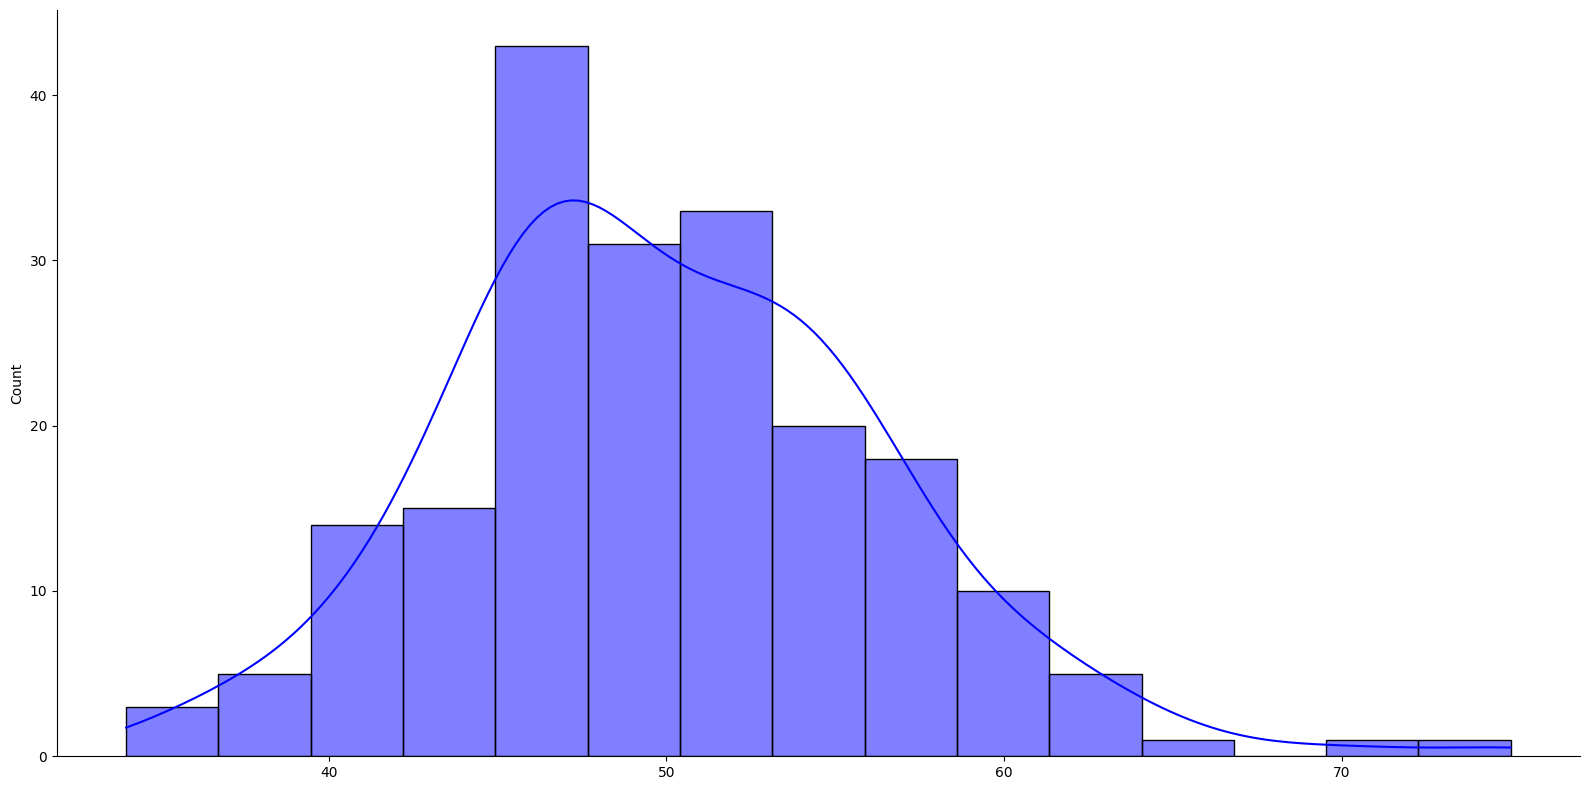

In [7]:
plt.figure(figsize=(16, 8))
sns.histplot(song_user.values, color="blue", kde=True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show();


In [8]:
print(f"A song is listened for an average of {np.mean(song_user)} users, with minimum {np.min(song_user)} and maximum {np.max(song_user)} users")

A song is listened for an average of 50.0 users, with minimum 34 and maximum 75 users


So we already know that it is a very sparse matrix. Dealing with such a sparse matrix, we'll take a lot of memory and resources. To make our life easier, let's just select again all those users that have listened to at least 16 songs. Moreover, we are going to select only those songs which have been listened to by at least 200 users.

In [9]:
# Get how many songs each user have listened to
user_counts = df_songs.groupby('user_id')['song_id'].count()

# Filter users which have listen to at least 16 songs
user_ten_id = user_counts[user_counts > 2].index.to_list()

In [10]:
# Get how many user have listened to each song
song_counts = df_songs.groupby('song_id')['user_id'].count()

# Get songs which have been listened at least 4 times
song_ten_id = song_counts[song_counts > 2].index.to_list() 

In [11]:
# Filtered the dataset to keep only those users with more than 16 listened
df_song_reduced = df_songs[(df_songs['user_id'].isin(user_ten_id)) & (df_songs['song_id'].isin(song_ten_id))].reset_index(drop=True)

In [12]:
df_song_reduced.shape

(10000, 7)

### Model and recommendations

Matrix Factorization is a powerful way to implement a recommendation system. The idea behind it is to represent users and items in a lower-dimensional latent space. 

So, in other words, Matrix factorization methods decompose the original sparse user-item matrix into lower dimensionality less sparse rectangular matrices with latent features.

This does not only solve the sparsity issue but also makes the method scalable. It doesn't matter how big the matrix is, you can always find lower dimensionality matrices that are a true representation of the original one.

Among the different matrix factorization techniques, we found the popular singular value decomposition (SVD).

This can be an abstract concept as we deepen into the mathematical foundations. But we'll try to keep it as simple as possible.
Imagine we have a matrix A that contains the data for n users x m songs. This matrix can be decomposed uniquely into 3 matrices; let's called them U, S, and V. 

In terms of our song recommender:

- U is an n users x r user-latent feature matrix
- V is an m songs x r song-latent feature matrix
- S is an r x r non-negative diagonal matrix containing the singular values of the original matrix.

Instead of working with the implicit rating as it is, we'll apply the binning technique.  
  
We'll define 10 categories. The original data values which fall into the interval from 0 to 1, will be replaced by the representative rating of 1; if they fall into the interval 1 to 2, they will be replaced by 2; and so on and so forth. The last category will be assigned to original values ranging from 9 to 2213.

In [13]:
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 2214]

In [14]:
df_song_reduced['listen_count'] = pd.cut(df_song_reduced['listen_count'], bins=bins, labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
df_song_reduced['listen_count'] = pd.to_numeric(df_song_reduced['listen_count'], errors='coerce').fillna(0).astype(int)

In [15]:
df_song_reduced['listen_count'] = pd.to_numeric(df_song_reduced['listen_count'], errors='coerce')
listen_counts = pd.DataFrame(df_song_reduced.groupby('listen_count').size(), columns=['count']).reset_index(drop=False)

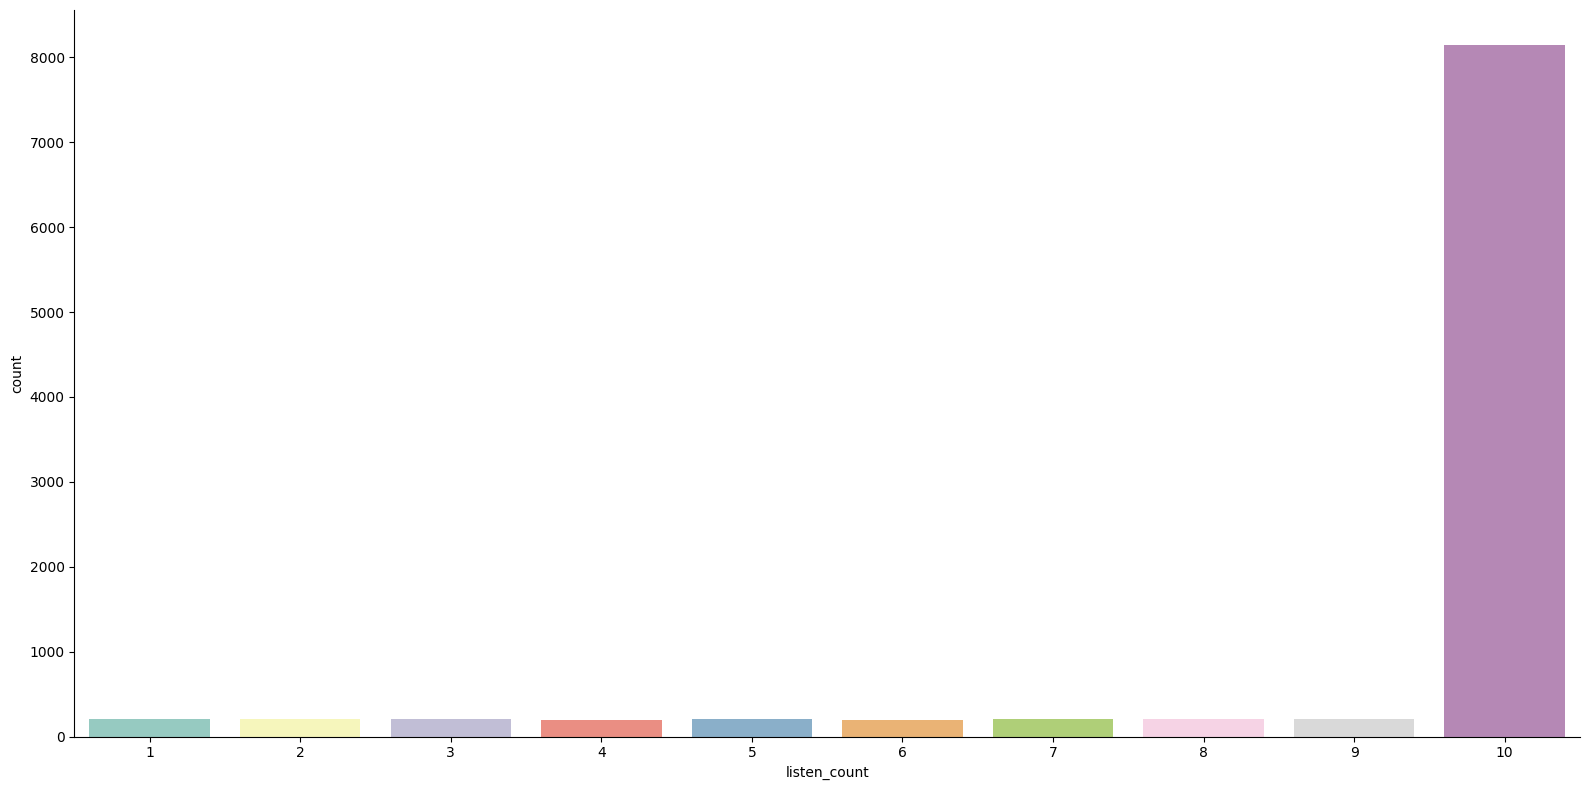

In [16]:
plt.figure(figsize=(16, 8))
sns.barplot(x="listen_count", y="count", hue="listen_count", palette="Set3", data=listen_counts, legend=False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show();


For this topic, we are going to use a fun package called `surprise`. Surprise is an easy-to-use Python library specially designed for recommender systems. 

To load a dataset from our DataFrame, we will use the load_from_df() method.

We will need to pass the following parameters:  

   - df: The dataframe containing the ratings. It must have three columns, corresponding to the user ids, the song ids, and the ratings.
   - reader (Reader): A reader to read the file. Only the rating_scale field needs to be specified.

In [17]:
# Aggregate duplicate (user_id, song_id) pairs before pivoting
df_song_agg = df_song_reduced.groupby(["user_id", "song_id"], as_index=False)["listen_count"].sum()

# Build a user-item matrix for SVD
pivot_df = df_song_agg.pivot_table(index="user_id", columns="song_id", values="listen_count", fill_value=0)
print(f"User-item matrix shape: {pivot_df.shape}")


User-item matrix shape: (500, 200)


And as always, we split the set into training and testing.

In [18]:
# Split user-item matrix rows for train/test
from sklearn.model_selection import train_test_split as sk_split
train_data, test_data = sk_split(pivot_df.values, test_size=0.25, random_state=42)
print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")


Train shape: (375, 200), Test shape: (125, 200)


We'll use the built-in function for SVD. First, a set of parameters is going to be defined to search for the best parameters for the model. 

The `GridSearchCV` class will compute accuracy metrics for the SVDalgorithm on the combinations of parameters selected, over a cross-validation procedure. This is useful for finding the best set of parameters for a prediction algorithm.

In [19]:
# SVD hyperparameter options (n_factors = number of latent features)
param_grid = {"n_factors": [20, 50, 100]}
print("Parameters to test:", param_grid)


Parameters to test: {'n_factors': [20, 50, 100]}


In [20]:
# Manual cross-validation to find best n_factors
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error
import numpy as np

def svd_predict(matrix, n_factors):
    """Decompose matrix using SVD and reconstruct predictions."""
    # Center the matrix
    user_mean = matrix.mean(axis=1, keepdims=True)
    centered = matrix - user_mean
    k = min(n_factors, min(centered.shape) - 1)
    U, sigma, Vt = svds(centered.astype(float), k=k)
    predicted = np.dot(np.dot(U, np.diag(sigma)), Vt) + user_mean
    return predicted

best_rmse = float("inf")
best_n_factors = None
for n_f in param_grid["n_factors"]:
    pred = svd_predict(train_data, n_f)
    # Only evaluate non-zero test entries
    mask = test_data > 0
    if mask.any():
        rmse = np.sqrt(mean_squared_error(test_data[mask], np.clip(pred[:test_data.shape[0]][:, :test_data.shape[1]][mask], 1, 10)))
    else:
        rmse = float("inf")
    print(f"n_factors={n_f}: RMSE={rmse:.4f}")
    if rmse < best_rmse:
        best_rmse = rmse
        best_n_factors = n_f

print(f"Best n_factors: {best_n_factors} (RMSE={best_rmse:.4f})")


n_factors=20: RMSE=8.5287
n_factors=50: RMSE=8.4249
n_factors=100: RMSE=8.4966
Best n_factors: 50 (RMSE=8.4249)


In [21]:
print(f"Best n_factors selected: {best_n_factors}")
print(f"Best RMSE: {best_rmse:.4f}")


Best n_factors selected: 50
Best RMSE: 8.4249


In [22]:
# 5-fold cross-validation on the full pivot matrix
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmses = []
X = pivot_df.values

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    pred = svd_predict(X_train, best_n_factors)
    mask = X_test > 0
    if mask.any():
        pred_test = pred[:X_test.shape[0], :X_test.shape[1]]
        rmse = np.sqrt(mean_squared_error(X_test[mask], np.clip(pred_test[mask], 1, 10)))
        cv_rmses.append(rmse)
        print(f"Fold {fold+1} RMSE: {rmse:.4f}")

print(f"Mean CV RMSE: {np.mean(cv_rmses):.4f} (+/- {np.std(cv_rmses):.4f})")


Fold 1 RMSE: 8.4528
Fold 2 RMSE: 8.7239
Fold 3 RMSE: 8.6152
Fold 4 RMSE: 8.5928
Fold 5 RMSE: 8.4697
Mean CV RMSE: 8.5709 (+/- 0.1000)


After finding the best parameters for the model, we create our final model, train it and find the error for the test set.

In [23]:
# Train final SVD model on full training data
final_predictions = svd_predict(train_data, best_n_factors)
mask = test_data > 0
if mask.any():
    test_pred_clipped = np.clip(final_predictions[:test_data.shape[0], :test_data.shape[1]][mask], 1, 10)
    final_rmse = np.sqrt(mean_squared_error(test_data[mask], test_pred_clipped))
    print(f"The RMSE is {final_rmse:.4f}")
else:
    print("No test entries to evaluate")


The RMSE is 8.4249
